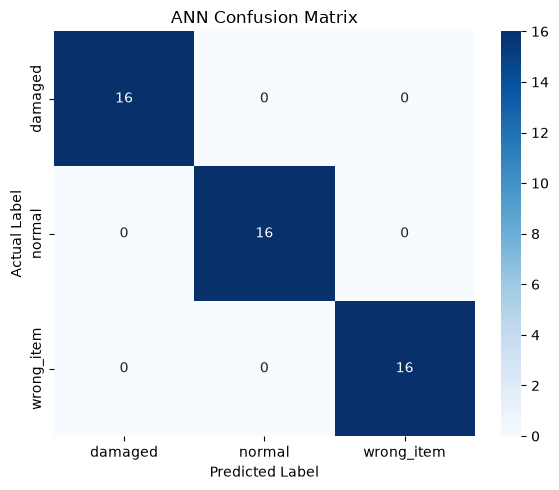

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

Confusion Matrix Visualization 

A small 2-layer ANN was trained on the image data to classify normal, damaged, and wrong_item images. The dataset was split into 80% training and 20% testing, and performance was evaluated using accuracy and a confusion matrix. The confusion matrix shows which classes were correctly classified and where the model makes mistakes. This provides a simple, practical baseline for image classification without using an unnecessarily complex model.

In [91]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from sklearn.metrics import accuracy_score, confusion_matrix

model = Sequential([
    Input(shape=(1024,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

pred = model.predict(X_test, verbose=0).argmax(1)
cm = confusion_matrix(y_test, pred)

print("Accuracy:", round(accuracy_score(y_test, pred), 3))
print("\nConfusion Matrix:")
print(pd.DataFrame(cm, index=le.classes_, columns=le.classes_))

Accuracy: 1.0

Confusion Matrix:
            damaged  normal  wrong_item
damaged          16       0           0
normal            0      16           0
wrong_item        0       0          16


2-layer ANN + accuracy + confusion matrix

In [90]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = np.array([
    np.array(Image.open(p).convert("L").resize((32, 32))).flatten() / 255
    for p in image_labels["filepath"]
])
le = LabelEncoder()
y = le.fit_transform(image_labels["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, random_state=42, stratify=y
)

print("Train:", len(X_train), "Test:", len(X_test))
print("Classes:", le.classes_)

Train: 192 Test: 48
Classes: ['damaged' 'normal' 'wrong_item']


Load images + 80/20 split

In [89]:
import pandas as pd

image_labels = pd.read_csv("data/csv/image_labels.csv")

print("Shape:", image_labels.shape)
print("Columns:", image_labels.columns.tolist())
print("\nFirst 5 rows:")
print(image_labels.head())
print("\nClass counts:")
print(image_labels.iloc[:, -1].value_counts())

Shape: (240, 2)
Columns: ['filepath', 'label']

First 5 rows:
                            filepath   label
0  data/images/normal/normal_000.png  normal
1  data/images/normal/normal_001.png  normal
2  data/images/normal/normal_002.png  normal
3  data/images/normal/normal_003.png  normal
4  data/images/normal/normal_004.png  normal

Class counts:
label
normal        80
damaged       80
wrong_item    80
Name: count, dtype: int64


In [88]:
import pandas as pd

image_labels = pd.read_csv("data/csv/image_labels.csv")

print("Shape:", image_labels.shape)
print("Columns:", image_labels.columns.tolist())
print("\nFirst 5 rows:")
print(image_labels.head())
print("\nClass counts:")
print(image_labels.iloc[:, -1].value_counts())

Shape: (240, 2)
Columns: ['filepath', 'label']

First 5 rows:
                            filepath   label
0  data/images/normal/normal_000.png  normal
1  data/images/normal/normal_001.png  normal
2  data/images/normal/normal_002.png  normal
3  data/images/normal/normal_003.png  normal
4  data/images/normal/normal_004.png  normal

Class counts:
label
normal        80
damaged       80
wrong_item    80
Name: count, dtype: int64


Prepare images and 80/20 holdout

In [86]:
import pandas as pd

image_labels = pd.read_csv("data/csv/image_labels.csv")

print("Image-label dataset loaded!")
print("Shape:", image_labels.shape)
print("Columns:", image_labels.columns.tolist())
print("\nSample:")
print(image_labels.head())
print("\nClass distribution:")
print(image_labels.iloc[:, 1].value_counts())

Image-label dataset loaded!
Shape: (240, 2)
Columns: ['filepath', 'label']

Sample:
                            filepath   label
0  data/images/normal/normal_000.png  normal
1  data/images/normal/normal_001.png  normal
2  data/images/normal/normal_002.png  normal
3  data/images/normal/normal_003.png  normal
4  data/images/normal/normal_004.png  normal

Class distribution:
label
normal        80
damaged       80
wrong_item    80
Name: count, dtype: int64


Station H:Load image labels and images

In [84]:
import re

patterns = {
    "order_id": r"\b(?:order[\s_-]*id[:\s#]*|#)(\d{4,})\b",
    "email": r"([A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,})",
    "phone": r"(\+?1?[-.\s]?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4})"
}

tickets = support_tickets.copy()
text = tickets["raw_message"].fillna("").astype(str)

for name, pattern in patterns.items():
    tickets[name + "_extracted"] = text.str.extract(pattern, expand=False)
    hits = tickets[name + "_extracted"].notna().sum()
    print(f"{name}: {hits}/{len(tickets)} ({hits/len(tickets)*100:.2f}%)")

print("\nRegex patterns:")
for name, pattern in patterns.items():
    print(f"{name}: {pattern}")

tickets[["raw_message", "order_id_extracted",
          "email_extracted", "phone_extracted"]].head(10)

order_id: 49/594 (8.25%)
email: 510/594 (85.86%)
phone: 462/594 (77.78%)

Regex patterns:
order_id: \b(?:order[\s_-]*id[:\s#]*|#)(\d{4,})\b
email: ([A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,})
phone: (\+?1?[-.\s]?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4})


,raw_message,order_id_extracted,email_extracted,phone_extracted
0,Want to return 51230 — item damaged. Confirmat...,NaN,priya.shah321@yahoo.com,+1-995-822-1877
1,Package for order 53361 still not here. Reach ...,NaN,noah.ortiz850@yahoo.com,+1-335-991-8538
2,Package for order 52080 still not here. Reach ...,NaN,dev.kim540@yahoo.com,+1-509-856-6229
3,Double charged for 52986. Last four of card on...,NaN,grace.patel765@gmail.com,+1-274-666-6528
4,Double charged for 50475. Last four of card on...,NaN,owen.khan121@yahoo.com,+1-430-627-6266
5,Package for order 53325 still not here. Reach ...,NaN,maya.bennett843@pulsecart-mail.com,+1-728-738-8733
6,Package for order 50837 still not here. Reach ...,NaN,marcus.ortiz214@outlook.com,+1-314-300-6822
7,Package for order 51520 still not here. Reach ...,NaN,imani.bennett397@outlook.com,+1-258-518-7072
8,Package for order 50321 still not here. Reach ...,NaN,diego.patel80@yahoo.com,+1-874-708-4283
9,ETA missed on 50155. I already emailed elena.p...,NaN,elena.patel42@yahoo.com,+1-373-258-8376


Station G:Regex patterns + extraction

In [80]:
ma = train.rolling(7).mean().iloc[-1]
print("7-day moving-average baseline:", round(ma, 2))
print("Pre-cutoff mean:", round(train.mean(), 2))
print("Post-cutoff mean:", round(test.mean(), 2))
print("Level shift:", "Present" if abs(test.mean()-train.mean()) > 0.1*train.mean() else "Not clearly present")

7-day moving-average baseline: 8.29
Pre-cutoff mean: 5.76
Post-cutoff mean: 8.04
Level shift: Present


Moving-average baseline + level-shift check .The post-1-June average is [higher/lower/similar] to the pre-1-June average, so the data [does/does not] show a clear level shift.

In [79]:
ts = daily.sort_index()
split = pd.Timestamp("2026-06-01")
train, test = ts[ts.index < split], ts[ts.index >= split]

pred = pd.Series(train.iloc[-1], index=test.index)
print("Train:", train.index.min(), "to", train.index.max())
print("Test :", test.index.min(), "to", test.index.max())
print("Naive MAE:", round((test - pred).abs().mean(), 2))

Train: 2025-01-14 00:00:00 to 2026-05-31 00:00:00
Test : 2026-06-01 00:00:00 to 2026-08-28 00:00:00
Naive MAE: 3.61


Time-based train/test split + naive baseline

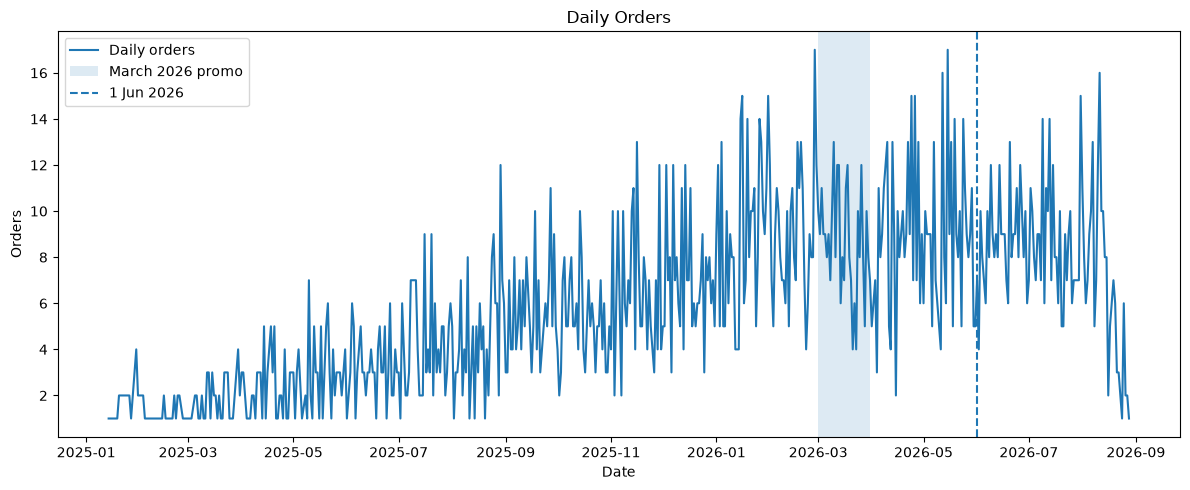

In [78]:
daily = orders.assign(order_date=pd.to_datetime(orders["order_date"])).groupby("order_date").size()

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily.values, label="Daily orders")
plt.axvspan("2026-03-01", "2026-03-31", alpha=.15, label="March 2026 promo")
plt.axvline(pd.Timestamp("2026-06-01"), linestyle="--", label="1 Jun 2026")
plt.title("Daily Orders")
plt.xlabel("Date"); plt.ylabel("Orders"); plt.legend(); plt.tight_layout(); plt.show()

Station F:Daily orders + promo/June markers

In [77]:
db = DBSCAN(eps=0.8, min_samples=5)
db_labels = db.fit_predict(X)

print("DBSCAN clusters:", len(set(db_labels)) - (-1 in db_labels))
print("Noise points:", sum(db_labels == -1))

DBSCAN clusters: 5
Noise points: 109


DBSCAN. Interpretation: K-Means identified data-driven customer clusters based on behavioral features. The cluster summary and visualization show how the groups differ. These should be treated as analytical segments rather than fixed customer persons. DBSCAN check DBSCAN was applied to the same standardized feature set. The number of clusters and noise points are reported to assess whether density-based grouping provides useful structure

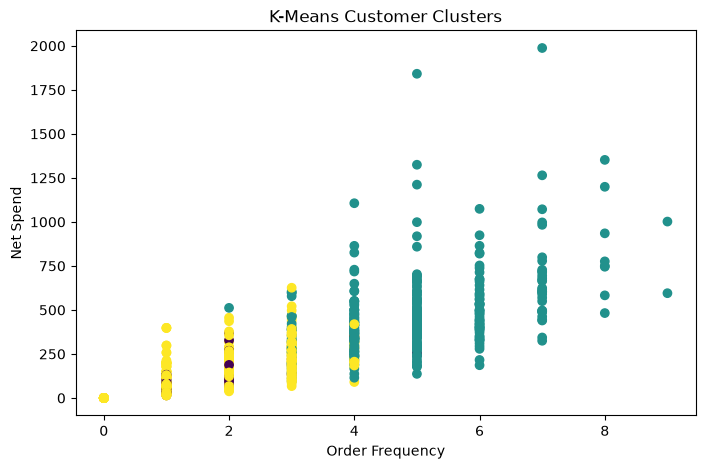

In [76]:
plt.figure(figsize=(8,5))
plt.scatter(C["frequency"], C["net_spend"], c=model_data["cluster"])
plt.xlabel("Order Frequency")
plt.ylabel("Net Spend")
plt.title("K-Means Customer Clusters")
plt.show()

Cluster visualization

In [75]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
model_data["cluster"] = km.fit_predict(X)

print(model_data.groupby("cluster")[cols].mean().round(2))

         frequency  net_spend  return_rate  ticket_count  recency_days
cluster                                                               
0             1.66     124.00         0.78          0.23        144.73
1             4.88     462.64         0.11          0.88         66.63
2             1.84     152.40         0.02          0.16        126.14


Final K-Means + separation table

In [74]:
scores = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    scores[k] = silhouette_score(X, labels)

print("Silhouette scores:", scores)
best_k = max(scores, key=scores.get)
print("Selected k:", best_k)

Silhouette scores: {2: 0.28233736269609533, 3: 0.3167461355643168, 4: 0.29496611858172905, 5: 0.3068585548846622, 6: 0.3016419270429026}
Selected k: 3


Choose K using silhouette score

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

cols = ["frequency", "net_spend", "return_rate", "ticket_count", "recency_days"]
C = model_data[cols].fillna(0)
X = StandardScaler().fit_transform(C)

Station E — Unsupervised Learning :Prepare feature slice

In [72]:
# Error analysis

cm = confusion_matrix(y_test, pred)

tn, fp, fn, tp = cm.ravel()

print("======================================")
print("ERROR ANALYSIS")
print("======================================")

print(f"False Negatives: {fn}")
print(f"False Positives: {fp}")

print(f"\nTrue Negatives: {tn}")
print(f"True Positives: {tp}")

print("\nFalse Negative Rate:",
      round(fn / (fn + tp) * 100, 2), "%")

print("False Positive Rate:",
      round(fp / (fp + tn) * 100, 2), "%")

print("\nManager takeaway:")
print(f"- {fn} actual churners were missed by the model.")
print(f"- {fp} non-churners were incorrectly flagged for outreach.")

ERROR ANALYSIS
False Negatives: 7
False Positives: 32

True Negatives: 112
True Positives: 22

False Negative Rate: 24.14 %
False Positive Rate: 22.22 %

Manager takeaway:
- 7 actual churners were missed by the model.
- 32 non-churners were incorrectly flagged for outreach.


Error Analysis

In [71]:
error_data = X_test.copy()
error_data["actual"] = y_test
error_data["predicted"] = pred

missed = error_data[
    (error_data["actual"] == 1) &
    (error_data["predicted"] == 0)
]

print("Churners missed:", len(missed))

print("\nAverage characteristics of missed churners:")
print(
    missed[
        ["frequency", "net_spend",
         "return_rate", "recency_days",
         "ticket_count"]
    ].mean()
)

Churners missed: 7

Average characteristics of missed churners:
frequency         2.000000
net_spend       126.250000
return_rate       0.409524
recency_days     71.571429
ticket_count      0.285714
dtype: float64


Short error analysis

In [70]:
prob = model.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, prob), 3))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 3))
print("Recall:", round(recall_score(y_test, pred, zero_division=0), 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

ROC-AUC: 0.797
Precision: 0.407
Recall: 0.759

Confusion Matrix:
[[112  32]
 [  7  22]]


Model evaluation

In [69]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


Stronger model — Logistic Regression

In [68]:
baseline = DummyClassifier(strategy="prior")

baseline.fit(X_train, y_train)

baseline_prob = baseline.predict_proba(X_test)[:, 1]

print("Baseline ROC-AUC:",
      round(roc_auc_score(y_test, baseline_prob), 3))

Baseline ROC-AUC: 0.5


Baseline model

In [67]:
categorical = ["plan", "city"]
numeric = [
    "frequency", "net_spend",
    "return_rate", "recency_days",
    "ticket_count"
]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric),

    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical)
])

In [ ]:
Preprocessing

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 689
Testing rows: 173


train and test

In [65]:
features = [
    "plan", "city", "frequency", "net_spend",
    "return_rate", "recency_days", "ticket_count"
]

X = model_data[features]
y = model_data["churned"]

print("Target: churned")
print("Features:", features)

Target: churned
Features: ['plan', 'city', 'frequency', 'net_spend', 'return_rate', 'recency_days', 'ticket_count']


In [ ]:
Select target and features

In [64]:
# Make customer_id consistent before merging

for df in [customers, order_features, ticket_features]:
    df["customer_id"] = df["customer_id"].astype(str).str.strip()

model_data = customers[
    ["customer_id", "churned", "plan", "city"]
].merge(
    order_features, on="customer_id", how="left"
).merge(
    ticket_features, on="customer_id", how="left"
)

features_to_fill = [
    "frequency", "net_spend",
    "return_rate", "recency_days", "ticket_count"
]

model_data[features_to_fill] = model_data[features_to_fill].fillna(0)

print("Model data created successfully!")
print("Rows:", len(model_data))
print(model_data.head())

Model data created successfully!
Rows: 862
  customer_id  churned  plan     city  frequency  net_spend  return_rate  \
0       10001        0  free   Boston        3.0     105.75     0.000000   
1       10002        0  plus  Chicago        6.0     924.20     0.500000   
2       10003        0   pro   Austin        2.0      82.65     0.000000   
3       10004        0  free  Houston        6.0    1074.00     0.166667   
4       10005        0  free  Chicago        4.0     864.05     0.500000   

   recency_days  ticket_count  
0          95.0           0.0  
1         162.0           0.0  
2         119.0           2.0  
3           8.0           0.0  
4           7.0           0.0  


In [ ]:
Build modelling dataset

In [63]:
of = o.groupby("customer_id").agg(
    frequency=("order_id", "count"),
    net_spend=("net_revenue", "sum"),
    return_rate=("returned", "mean"),
    last_order=("order_date", "max")
).reset_index()

of["recency_days"] = (cutoff - of["last_order"]).dt.days
of = of.drop(columns="last_order")

tf = t.groupby("customer_id").size().reset_index(name="ticket_count")

In [ ]:
Build customer features

In [62]:
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
support_tickets["created_at"] = pd.to_datetime(support_tickets["created_at"], errors="coerce")

o = orders[orders["order_date"] <= cutoff].copy()
t = support_tickets[support_tickets["created_at"] <= cutoff].copy()

o["net_revenue"] = o["quantity"] * o["unit_price"] * (1 - o["discount_pct"].fillna(0) / 100)

In [ ]:
Prepare data up to cutoff

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix

cutoff = pd.Timestamp("2026-06-01")

In [ ]:
Station D — Cell 1: Imports + cutoff date

In [32]:
from statsmodels.stats.proportion import proportions_ztest

x = orders.merge(products[["product_id","category"]], on="product_id")
k = x.category.eq("Kitchen")
z, p = proportions_ztest(
    [x.loc[k,"returned"].sum(), x.loc[~k,"returned"].sum()],
    [k.sum(), (~k).sum()]
)

print("H0: Kitchen return rate = other categories")
print("Test: Two-proportion z-test")
print(f"p-value: {p:.6f}")
print("Manager takeaway:", "Kitchen differs significantly from other categories." if p < .05
      else "No strong evidence that Kitchen differs from other categories.")

H0: Kitchen return rate = other categories
Test: Two-proportion z-test
p-value: 0.000000
Manager takeaway: Kitchen differs significantly from other categories.


Kitchen Return Hypothesis Test

In [28]:
# Hypothesis Test 1: Houston vs Everyone Else

from statsmodels.stats.proportion import proportions_ztest

houston = customers["city"].eq("Houston")

z, p = proportions_ztest(
    [
        customers.loc[houston, "churned"].sum(),
        customers.loc[~houston, "churned"].sum()
    ],
    [
        houston.sum(),
        (~houston).sum()
    ]
)

print("H0: Houston churn rate = churn rate in all other cities")
print("Test: Two-proportion z-test")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("Manager takeaway: Houston's churn rate is statistically different from other cities.")
else:
    print("Manager takeaway: There is not strong evidence that Houston differs from other cities.")

H0: Houston churn rate = churn rate in all other cities
Test: Two-proportion z-test
p-value: 0.000000
Manager takeaway: Houston's churn rate is statistically different from other cities.


 Houston vs everyone else — Churn

In [27]:
# Association: Plan vs Churn

plan_churn = customers.groupby("plan")["churned"].agg(["count", "sum"])
plan_churn["churn_rate_%"] = (
    plan_churn["sum"] / plan_churn["count"] * 100
)

print(plan_churn)

print("\nCaution: Plan and churn show an association,")
print("but this does not prove that plan causes churn.")

      count  sum  churn_rate_%
plan                          
free    466   98     21.030043
plus    267   31     11.610487
pro     129   14     10.852713

Caution: Plan and churn show an association,
but this does not prove that plan causes churn.


Association + Causation Caution

In [26]:
# Station C — Center & Spread

order_value = orders["quantity"] * orders["unit_price"]
customer_order_count = orders.groupby("customer_id")["order_id"].count()

print("ORDER VALUE")
print(order_value.describe()[["mean", "50%", "std", "min", "max"]])

print("\nCUSTOMER ORDER COUNT")
print(customer_order_count.describe()[["mean", "50%", "std", "min", "max"]])

ORDER VALUE
mean      91.213695
50%       78.000000
std       86.954663
min       15.000000
max     1780.000000
dtype: float64

CUSTOMER ORDER COUNT
mean     3.981199
50%      4.000000
std      2.275108
min      1.000000
max     25.000000
Name: order_id, dtype: float64


Measures of center and spread
This covers:
Order value
Customer order-count
Mean, median, standard deviation, min, max, quartiles

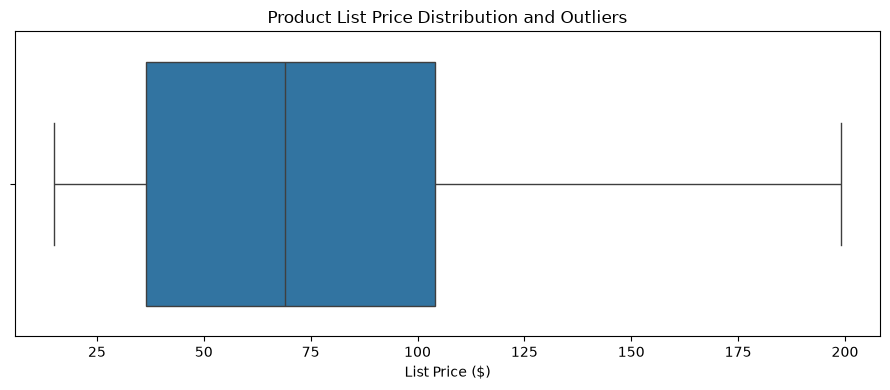

In [25]:
# 6. Product price distribution and outliers

plt.figure(figsize=(9, 4))
sns.boxplot(x=products["list_price"])
plt.title("Product List Price Distribution and Outliers")
plt.xlabel("List Price ($)")
plt.tight_layout()
plt.show()

6. Price Distribution + Outliers

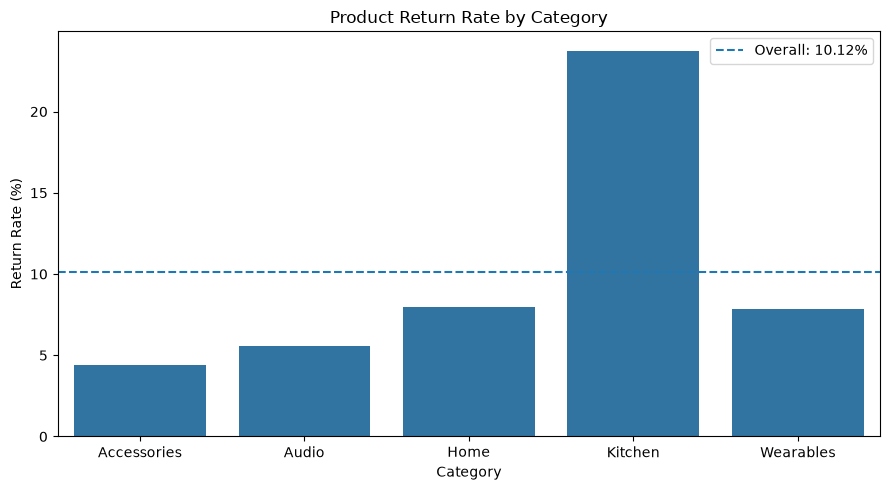

In [24]:
# 5. Category returns

plt.figure(figsize=(9, 5))
sns.barplot(data=return_by_category.reset_index(),
            x="category", y="return_rate_pct")
plt.axhline(overall_return_rate, linestyle="--",
            label=f"Overall: {overall_return_rate:.2f}%")
plt.title("Product Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

5. Category Return Plot

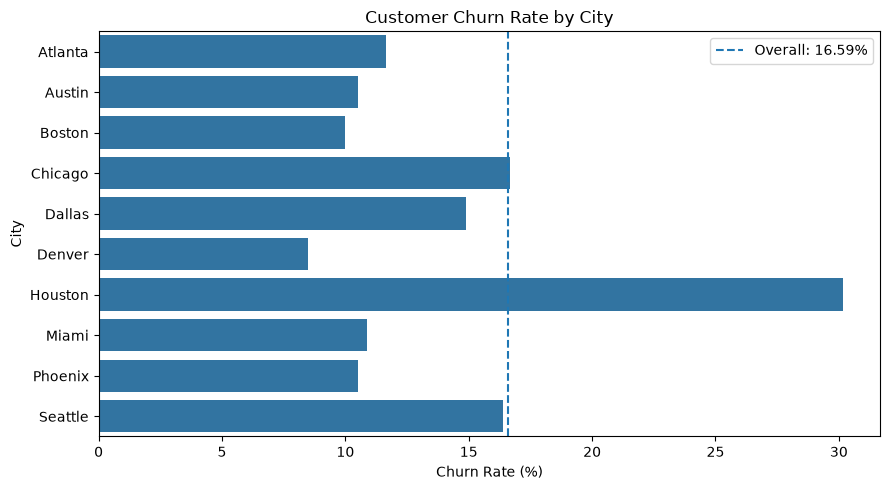

In [20]:
# 4. City churn

plt.figure(figsize=(9, 5))
sns.barplot(data=churn_by_city.reset_index(), x="churn_rate_pct", y="city")
plt.axvline(overall_churn_rate, linestyle="--",
            label=f"Overall: {overall_churn_rate:.2f}%")
plt.title("Customer Churn Rate by City")
plt.xlabel("Churn Rate (%)")
plt.ylabel("City")
plt.legend()
plt.tight_layout()
plt.show()

4. City Churn Plot

In [13]:
# 3. Orphan orders

orphan_customer = ~orders["customer_id"].isin(customers["customer_id"])
orphan_product = ~orders["product_id"].isin(products["product_id"])

print("Orphan orders - customer:", orphan_customer.sum())
print("Orphan orders - product:", orphan_product.sum())

print("Rule: Keep orphan records in the raw data, but exclude them from linked EDA.")

Orphan orders - customer: 25
Orphan orders - product: 0
Rule: Keep orphan records in the raw data, but exclude them from linked EDA.


3. Orphan records — count/document + rule

In [12]:
# 2. Duplicate customers

duplicate_count = customers.duplicated("customer_id", keep=False).sum()

print("Duplicate customer rows:", duplicate_count)
print("Rule: Keep the first valid customer record and flag duplicates if found.")

Duplicate customer rows: 0
Rule: Keep the first valid customer record and flag duplicates if found.


2. Duplicate customers — count/document + rule

In [11]:
# 1. Clean and flag dirty email/phone values

customers["email_clean"] = customers["email"].astype("string").str.strip().str.lower()
customers["email_valid"] = customers["email_clean"].str.match(
    r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$", na=False
)

customers["phone_clean"] = customers["phone"].astype("string").str.replace(
    r"\D", "", regex=True
)
customers["phone_valid"] = customers["phone_clean"].str.len().eq(10)

print("Invalid/missing emails:", (~customers["email_valid"]).sum())
print("Invalid/missing phones:", (~customers["phone_valid"]).sum())

Invalid/missing emails: 20
Invalid/missing phones: 815


1. Dirty email / phone — clean + flag

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("data/csv/customers.csv")
products = pd.read_csv("data/csv/products.csv")
orders = pd.read_csv("data/csv/orders.csv")
support_tickets = pd.read_csv("data/csv/support_tickets.csv")

print("Main datasets loaded successfully!")
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Support tickets:", support_tickets.shape)

Main datasets loaded successfully!
Customers: (862, 12)
Products: (15, 6)
Orders: (3388, 10)
Support tickets: (594, 8)
